# FIDE Ratings Analysis!

## Building the longitudinal dataset

Downloads every monthly FIDE rating list from July 2015 to today and parses each one into a typed parquet file. Unlike v1 (which loaded all 1.8M players into memory at once and crashed), this streams through the XML one player at a time, filters out unrated entries, and writes in chunks — so peak memory stays flat regardless of file size. Fully resumable: re-running skips anything already on disk.

Before any analysis, we need the raw data in a form we can actually work with. This section downloads every FIDE monthly rating list from July 2015 onward, filters out unrated players, converts types, and saves each month as its own parquet file. It's the "prep work" — run once, then every analysis below just loads what it needs.

Run time of this cell: Roughly 10 minutes in total, but it's fully resumable and safe to interrupt. It checks for existing files before downloading or processing, so if you stop it halfway, just run it again and it'll pick up where it left off.

**Note on rate limiting:**
 There is a 1-second pause between each file download (`SLEEP_BETWEEN = 1.0`). This is standard web scraping etiquette — hitting a server with 130 rapid requests risks getting your IP blocked and degrades the experience for other users on the site. The delay keeps the pipeline polite and stable. Adjust `SLEEP_BETWEEN` in `fide_pipeline.py` if needed, but don't set it below `0.5`.

In [8]:
from build_dataset import load_snapshots, load_snapshot_counts

/Users/anna/PycharmProjects/fide-rating_analysisV2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Sense check

Coverage, sex breakdown, top players, and a quick timeline plot.

In [9]:
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path("data/fide_parquet")
files = sorted(PARQUET_DIR.glob("*.parquet"))
latest = pd.read_parquet(files[-1])

print(f"{len(files)} months  •  {files[0].stem} → {files[-1].stem}")
print(f"{len(latest):,} active players in {files[-1].stem}  ({(latest.sex == 'F').mean()*100:.1f}% female)")
print(f"{sum(f.stat().st_size for f in files)/1e9:.2f} GB on disk\n")

cols = ["name", "country", "rating", "birthday"]
display(latest[latest.sex == "M"].nlargest(5, "rating")[cols].reset_index(drop=True))
display(latest[latest.sex == "F"].nlargest(5, "rating")[cols].reset_index(drop=True))

130 months  •  2015-07 → 2026-04
545,549 active players in 2026-04  (11.0% female)
1.10 GB on disk



,name,country,rating,birthday
0,"Carlsen, Magnus",NOR,2840,1990.0
1,"Kasparov, Garry",RUS,2812,1963.0
2,"Nakamura, Hikaru",USA,2810,1987.0
3,"Caruana, Fabiano",USA,2793,1992.0
4,"Abdusattorov, Nodirbek",UZB,2780,2004.0


,name,country,rating,birthday
0,"Polgar, Judit",HUN,2675,1976.0
1,"Hou, Yifan",CHN,2596,1994.0
2,"Polgar, Susan",HUN,2577,1969.0
3,"Xie, Jun",CHN,2574,1970.0
4,"Lei, Tingjie",CHN,2566,1997.0


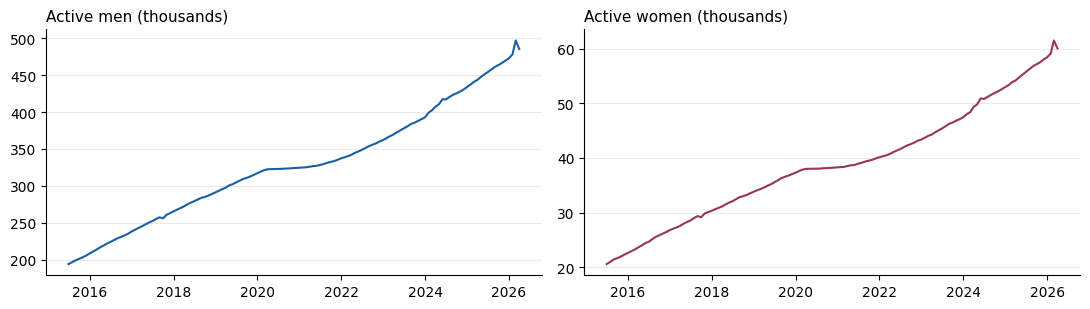

In [10]:
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

dataset = ds.dataset("data/fide_parquet", format="parquet")

def counts(sex):
    t = dataset.to_table(columns=["snapshot_date", "fideid"], filter=ds.field("sex") == sex)
    return t.to_pandas().groupby("snapshot_date").size().rename("n").reset_index()

m, f = counts("M"), counts("F")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
ax1.plot(m.snapshot_date, m.n/1000, color="#185FA5", lw=1.5)
ax1.set_title("Active men (thousands)", loc="left", fontsize=11)
ax2.plot(f.snapshot_date, f.n/1000, color="#993556", lw=1.5)
ax2.set_title("Active women (thousands)", loc="left", fontsize=11)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

In [11]:
import pyarrow.dataset as ds

fide_all = ds.dataset("data/fide_parquet", format="parquet")

#### As a note the full dataset is called fide_all and the snapshot of the most recent month is called latest.

### Question 1: Queen's Gambit effect — did the show cause a surge in new female players?

The Queen's Gambit premiered on Netflix in October 2020 and became a cultural phenomenon, sparking widespread interest in chess. To investigate whether the show led to a surge in new female players, we can analyze the monthly counts of active female players in the FIDE dataset before and after the show's release.

Text(0.0, 1.0, 'Active Female Players in 2020')

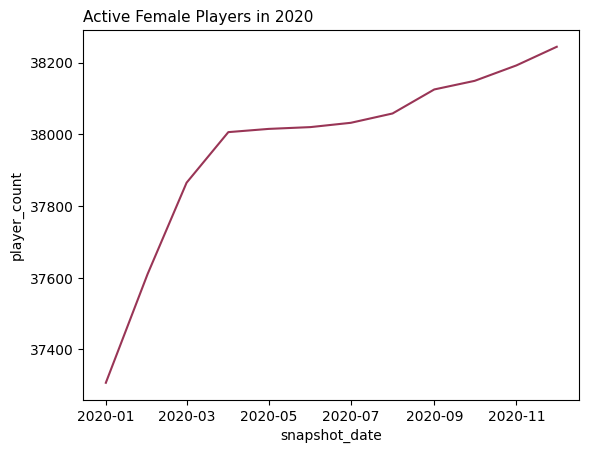

In [13]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F")
df_2020 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2020, 12, 1))]

sns.lineplot(df_2020, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2020", loc="left", fontsize=11)


Text(0.0, 1.0, 'Active Female Players in 2021')

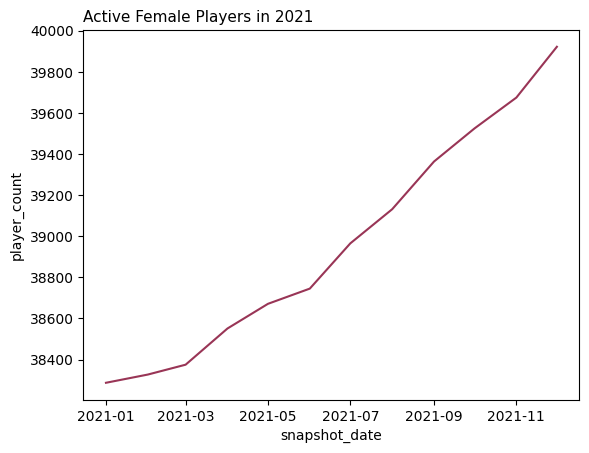

In [15]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F")
df_2021 = df[(df.snapshot_date >= date(2021, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2020, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2021", loc="left", fontsize=11)

(array([18262., 18353., 18444., 18536., 18628., 18718., 18809., 18901.,
        18993.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04'),
  Text(18444.0, 0, '2020-07'),
  Text(18536.0, 0, '2020-10'),
  Text(18628.0, 0, '2021-01'),
  Text(18718.0, 0, '2021-04'),
  Text(18809.0, 0, '2021-07'),
  Text(18901.0, 0, '2021-10'),
  Text(18993.0, 0, '2022-01')])

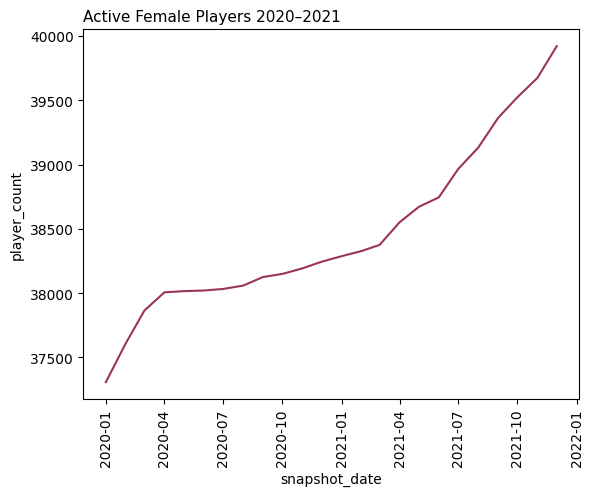

In [17]:
df = load_snapshot_counts(sex="F")
df_2020_21 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2020_21, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players 2020–2021", loc="left", fontsize=11)
plt.xticks(rotation=90)